In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from network_time_varying import TimeVaryingFeedForward

In [7]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

In [8]:
net = TimeVaryingFeedForward(time_varying=True)
net.run()

setting seed: 100
Inh scale timeline: [1.  1.  1.  1.  1.  1.  1.  0.6 0.6 0.6 0.6 0.6 0.6 0.6 1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]


100%|██████████| 840/840 [00:10<00:00, 77.96it/s]


In [9]:
net_partial_mod = TimeVaryingFeedForward(time_varying=True, partial_modulation=True)
net_partial_mod.run()

setting seed: 100
Inh scale timeline: [1.  1.  1.  1.  1.  1.  1.  0.6 0.6 0.6 0.6 0.6 0.6 0.6 1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]


100%|██████████| 840/840 [00:10<00:00, 81.24it/s]


In [10]:
drift_mag, drift_rate, convergence = net.get_metrics(net.N, net.n_days, net.theta_stim, net.POs)

drift_mag_partial_mod, drift_rate_partial_mod, convergence_partial_mod = net_partial_mod.get_metrics(net_partial_mod.N, net_partial_mod.n_days, net_partial_mod.theta_stim, net_partial_mod.POs)

<>:26: SyntaxWarning: invalid escape sequence '\;'
<>:26: SyntaxWarning: invalid escape sequence '\;'
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_95231/3435349447.py:26: SyntaxWarning: invalid escape sequence '\;'
  axs[2].set_ylabel('convergence $ \; [\degree]$')
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_95231/3435349447.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


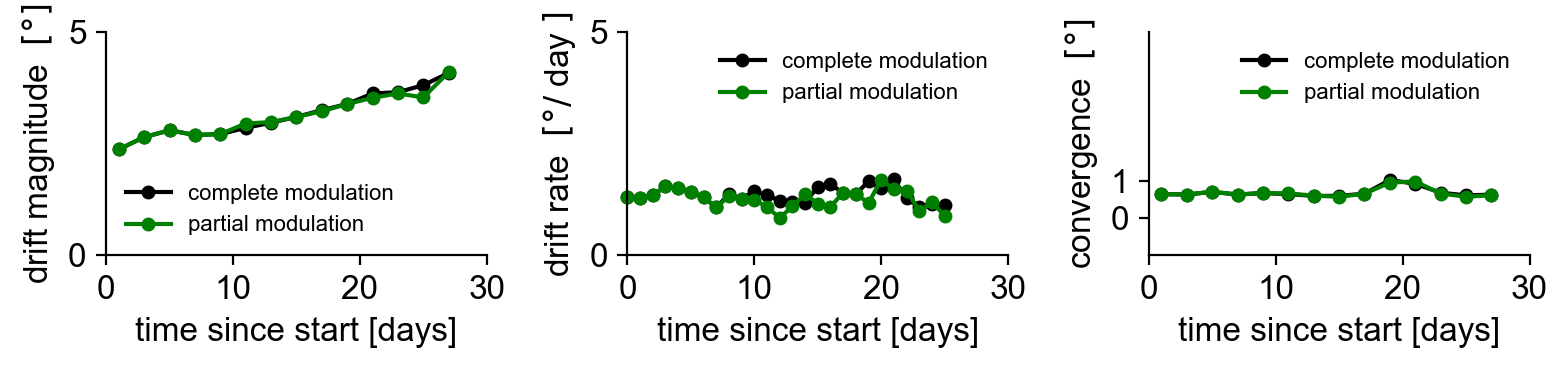

In [12]:
eo = 2


fig, axs = plt.subplots(1, 3, figsize=(8, 2), dpi=200)
axs[0].plot(np.arange(1, net.n_days)[::eo], np.median(drift_mag, axis=1)[:-1][::eo], c='black', ls='-', marker='o', ms=4, label='complete modulation', clip_on=False)
axs[0].plot(np.arange(1, net_partial_mod.n_days)[::eo], np.median(drift_mag_partial_mod, axis=1)[:-1][::eo], c='green', ls='-', marker='o', ms=4, label='partial modulation', clip_on=False)
axs[0].set_ylim([0, 5]); axs[0].set_yticks([0, 5])
axs[0].set_xlabel('time since start [days]')
axs[0].set_ylabel(r'drift magnitude $ \; [\degree]$')
axs[0].set_xlim(0, 30)
axs[0].legend(frameon=False, fontsize=8)


axs[1].plot(np.mean(drift_rate, axis=1)[:-1], c='black', ls='-', marker='o', ms=4, label='complete modulation', clip_on=False)
axs[1].plot(np.mean(drift_rate_partial_mod, axis=1)[:-1], c='green', ls='-', marker='o', ms=4, label='partial modulation', clip_on=False)
axs[1].set_ylim([0, 5]); axs[1].set_yticks([0, 5])
axs[1].set_xlabel('time since start [days]')
axs[1].set_ylabel(r'drift rate $ \; [\degree / $ day $]$')
axs[1].set_xlim(0, 30)  
axs[1].legend(frameon=False, fontsize=8)

axs[2].plot(np.arange(1, net.n_days)[::eo], np.median(convergence, axis=1)[::eo], c='black', ls='-', marker='o', ms=4, label='complete modulation', clip_on=False)
axs[2].plot(np.arange(1, net_partial_mod.n_days)[::eo], np.median(convergence_partial_mod, axis=1)[::eo], c='green', ls='-', marker='o', ms=4, label='partial modulation', clip_on=False)
axs[2].set_ylim([-1, 5]); axs[2].set_yticks([0, 1])
axs[2].set_xlabel('time since start [days]')
axs[2].set_ylabel('convergence $ \; [\degree]$')
axs[2].set_xlim(0, 30)
axs[2].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.show()

In [13]:
probe_angle = 45
exc_pop_activity_day_1, inh_pop_activity_day_1 = net.estimate_pop_activity_at_day(1, probe_angle)
exc_pop_activity_day_8, inh_pop_activity_day_8 = net.estimate_pop_activity_at_day(8, probe_angle)

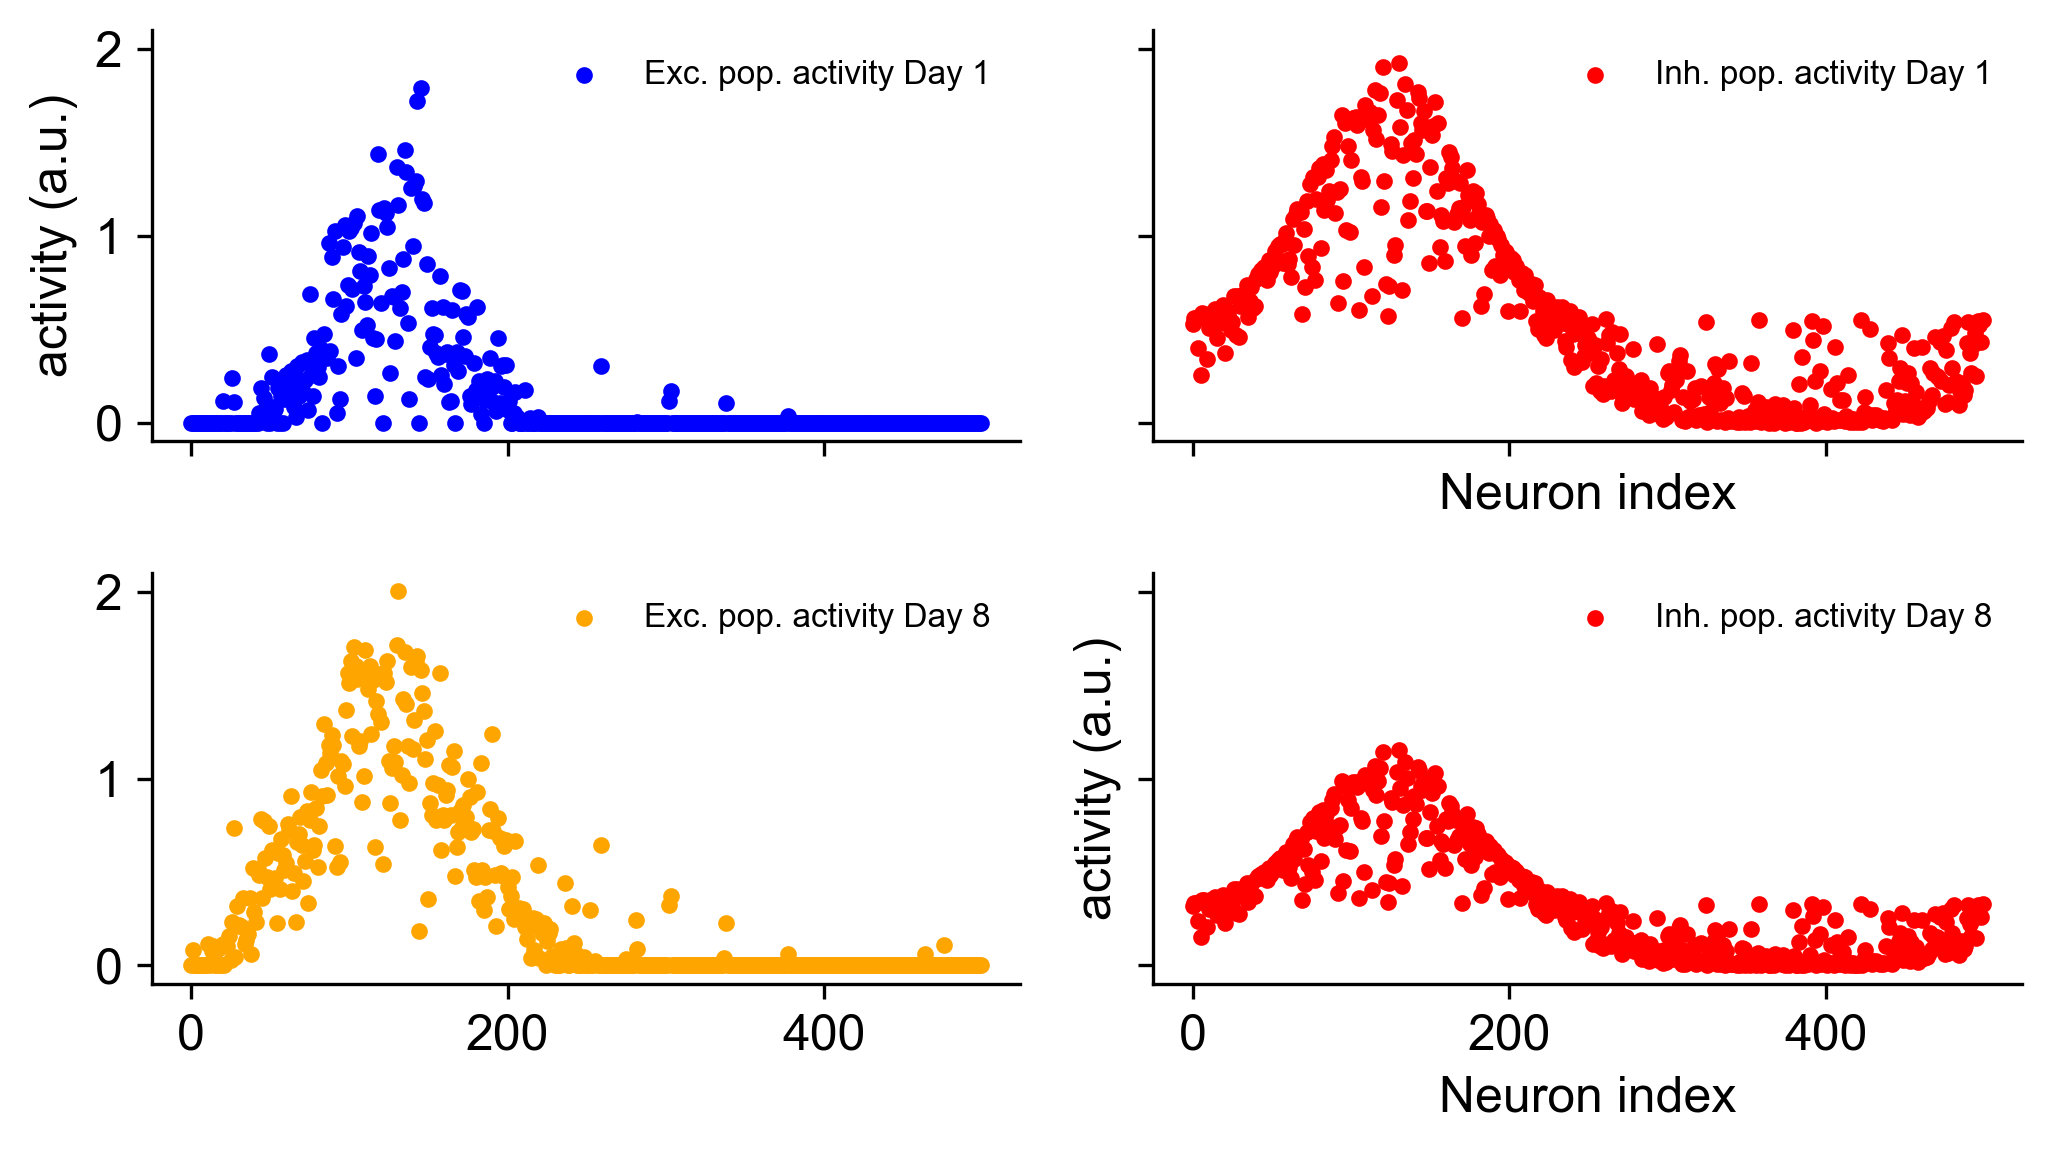

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(7, 4), dpi=300, sharex=True, sharey=True)

nrn_idx_range = np.arange(net.N)
# make scatter of activity points at day 1 and day 8 for excitatory population
axs[0, 0].scatter(nrn_idx_range, exc_pop_activity_day_1, c='blue', marker='.', label='Exc. pop. activity Day 1')
axs[1, 0].scatter(nrn_idx_range, exc_pop_activity_day_8, c='orange', marker='.', label='Exc. pop. activity Day 8')

axs[0, 0].legend(frameon=False, fontsize=8)
axs[1, 0].legend(frameon=False, fontsize=8)
# axs[0, 0].set_xlabel('Neuron index')
axs[0, 0].set_ylabel('activity (a.u.)')

axs[0, 1].scatter(nrn_idx_range, inh_pop_activity_day_1, c='red', marker='.', label='Inh. pop. activity Day 1')
axs[1, 1].scatter(nrn_idx_range, inh_pop_activity_day_8, c='red', marker='.', label='Inh. pop. activity Day 8')

axs[0, 1].legend(frameon=False, fontsize=8)
axs[1, 1].legend(frameon=False, fontsize=8)


axs[0, 1].set_xlabel('Neuron index')
axs[1, 1].set_xlabel('Neuron index')
axs[1, 1].set_ylabel('activity (a.u.)')

fig.tight_layout()

In [15]:
probe_angle = 45

exc_pop_activity_day_1_partial_mod, inh_pop_activity_day_1_partial_mod = net_partial_mod.estimate_pop_activity_at_day(1, probe_angle)
exc_pop_activity_day_8_partial_mod, inh_pop_activity_day_8_partial_mod = net_partial_mod.estimate_pop_activity_at_day(8, probe_angle)

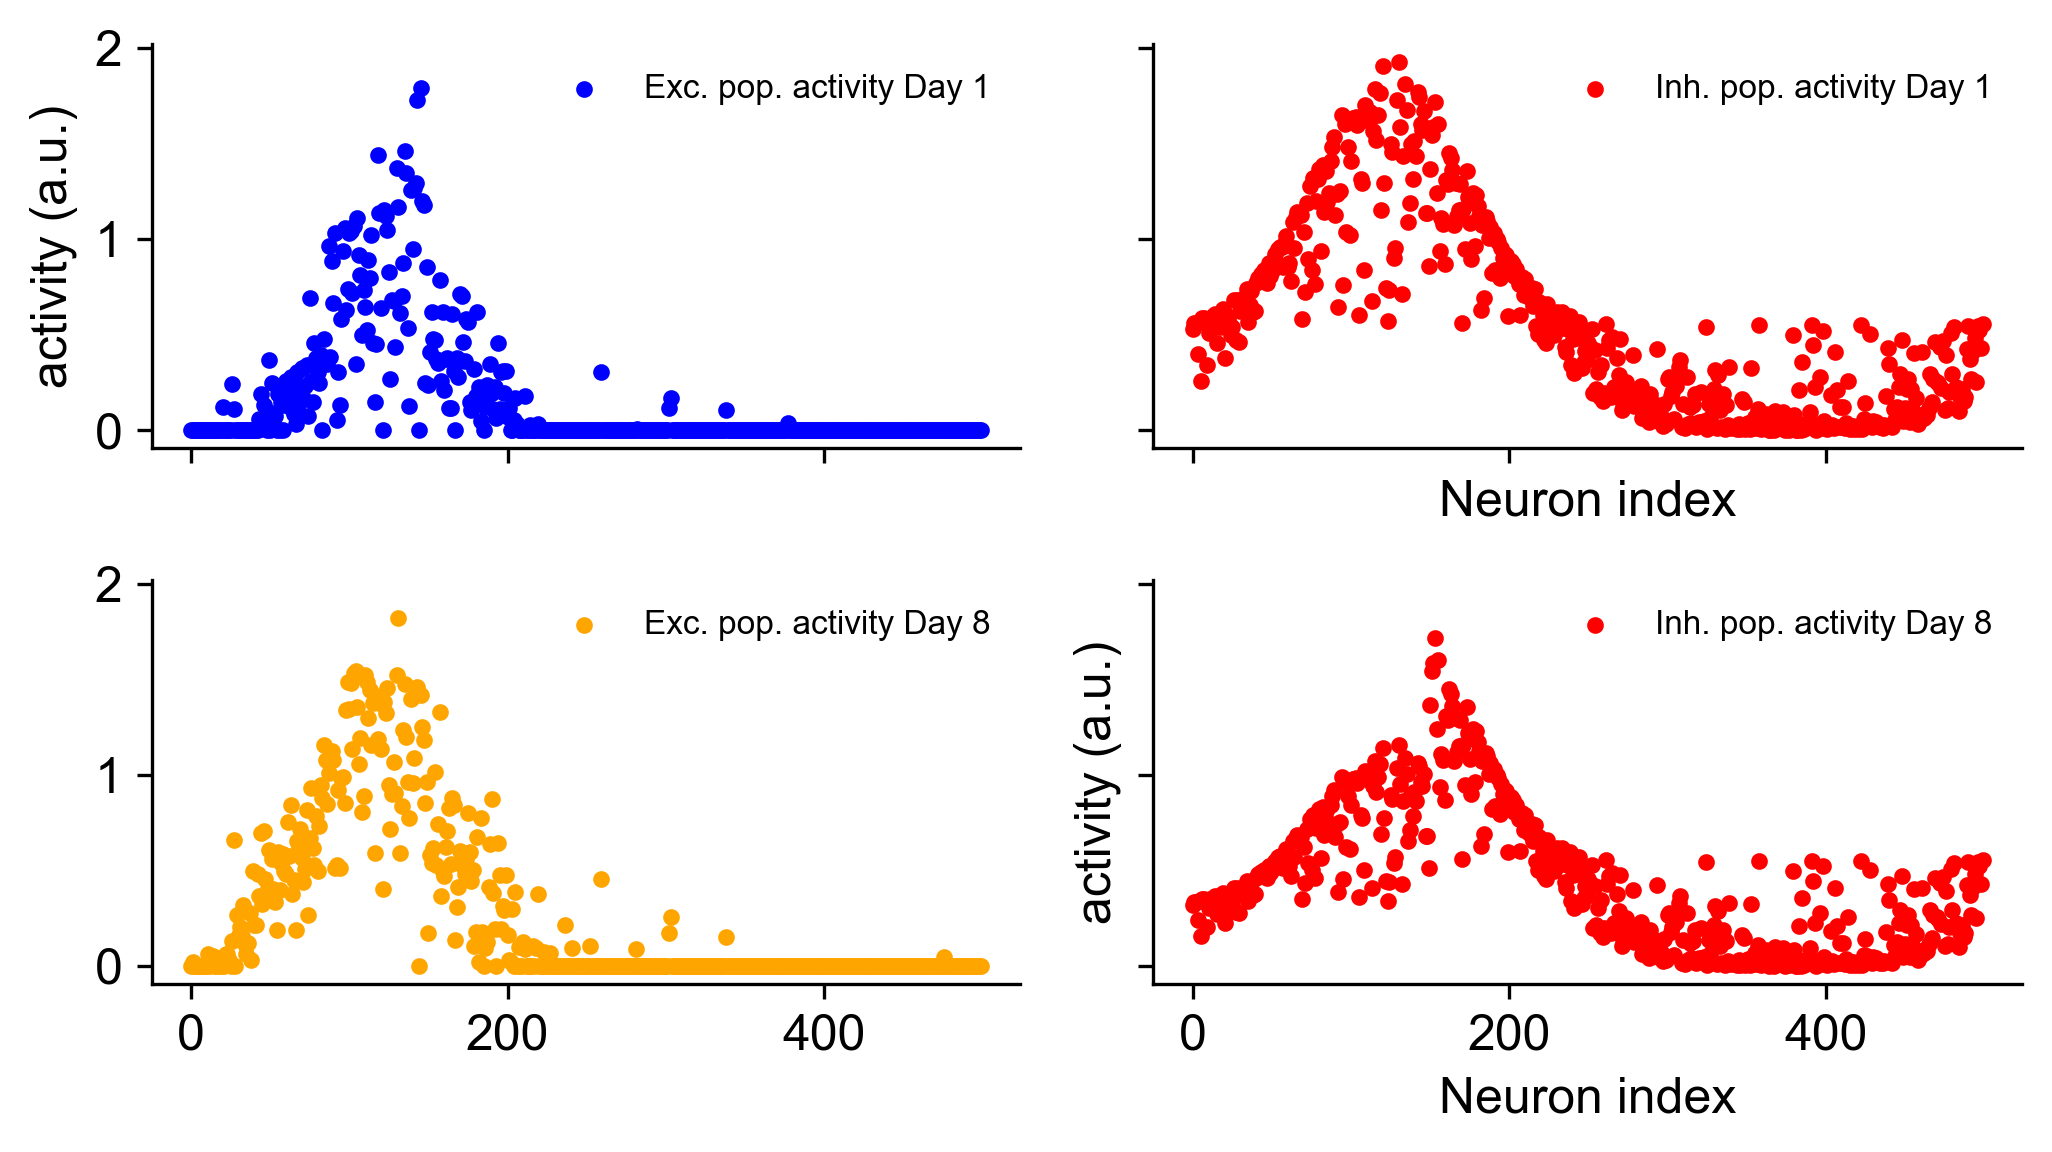

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(7, 4), dpi=300, sharex=True, sharey=True)

nrn_idx_range = np.arange(net.N)
# make scatter of activity points at day 1 and day 8 for excitatory population
axs[0, 0].scatter(nrn_idx_range, exc_pop_activity_day_1_partial_mod, c='blue', marker='.', label='Exc. pop. activity Day 1')
axs[1, 0].scatter(nrn_idx_range, exc_pop_activity_day_8_partial_mod, c='orange', marker='.', label='Exc. pop. activity Day 8')

axs[0, 0].legend(frameon=False, fontsize=8)
axs[1, 0].legend(frameon=False, fontsize=8)
# axs[0, 0].set_xlabel('Neuron index')
axs[0, 0].set_ylabel('activity (a.u.)')

axs[0, 1].scatter(nrn_idx_range, inh_pop_activity_day_1_partial_mod, c='red', marker='.', label='Inh. pop. activity Day 1')
axs[1, 1].scatter(nrn_idx_range, inh_pop_activity_day_8_partial_mod, c='red', marker='.', label='Inh. pop. activity Day 8')

axs[0, 1].legend(frameon=False, fontsize=8)
axs[1, 1].legend(frameon=False, fontsize=8)

axs[0, 1].set_xlabel('Neuron index')
axs[1, 1].set_xlabel('Neuron index')
axs[1, 1].set_ylabel('activity (a.u.)')


fig.tight_layout()

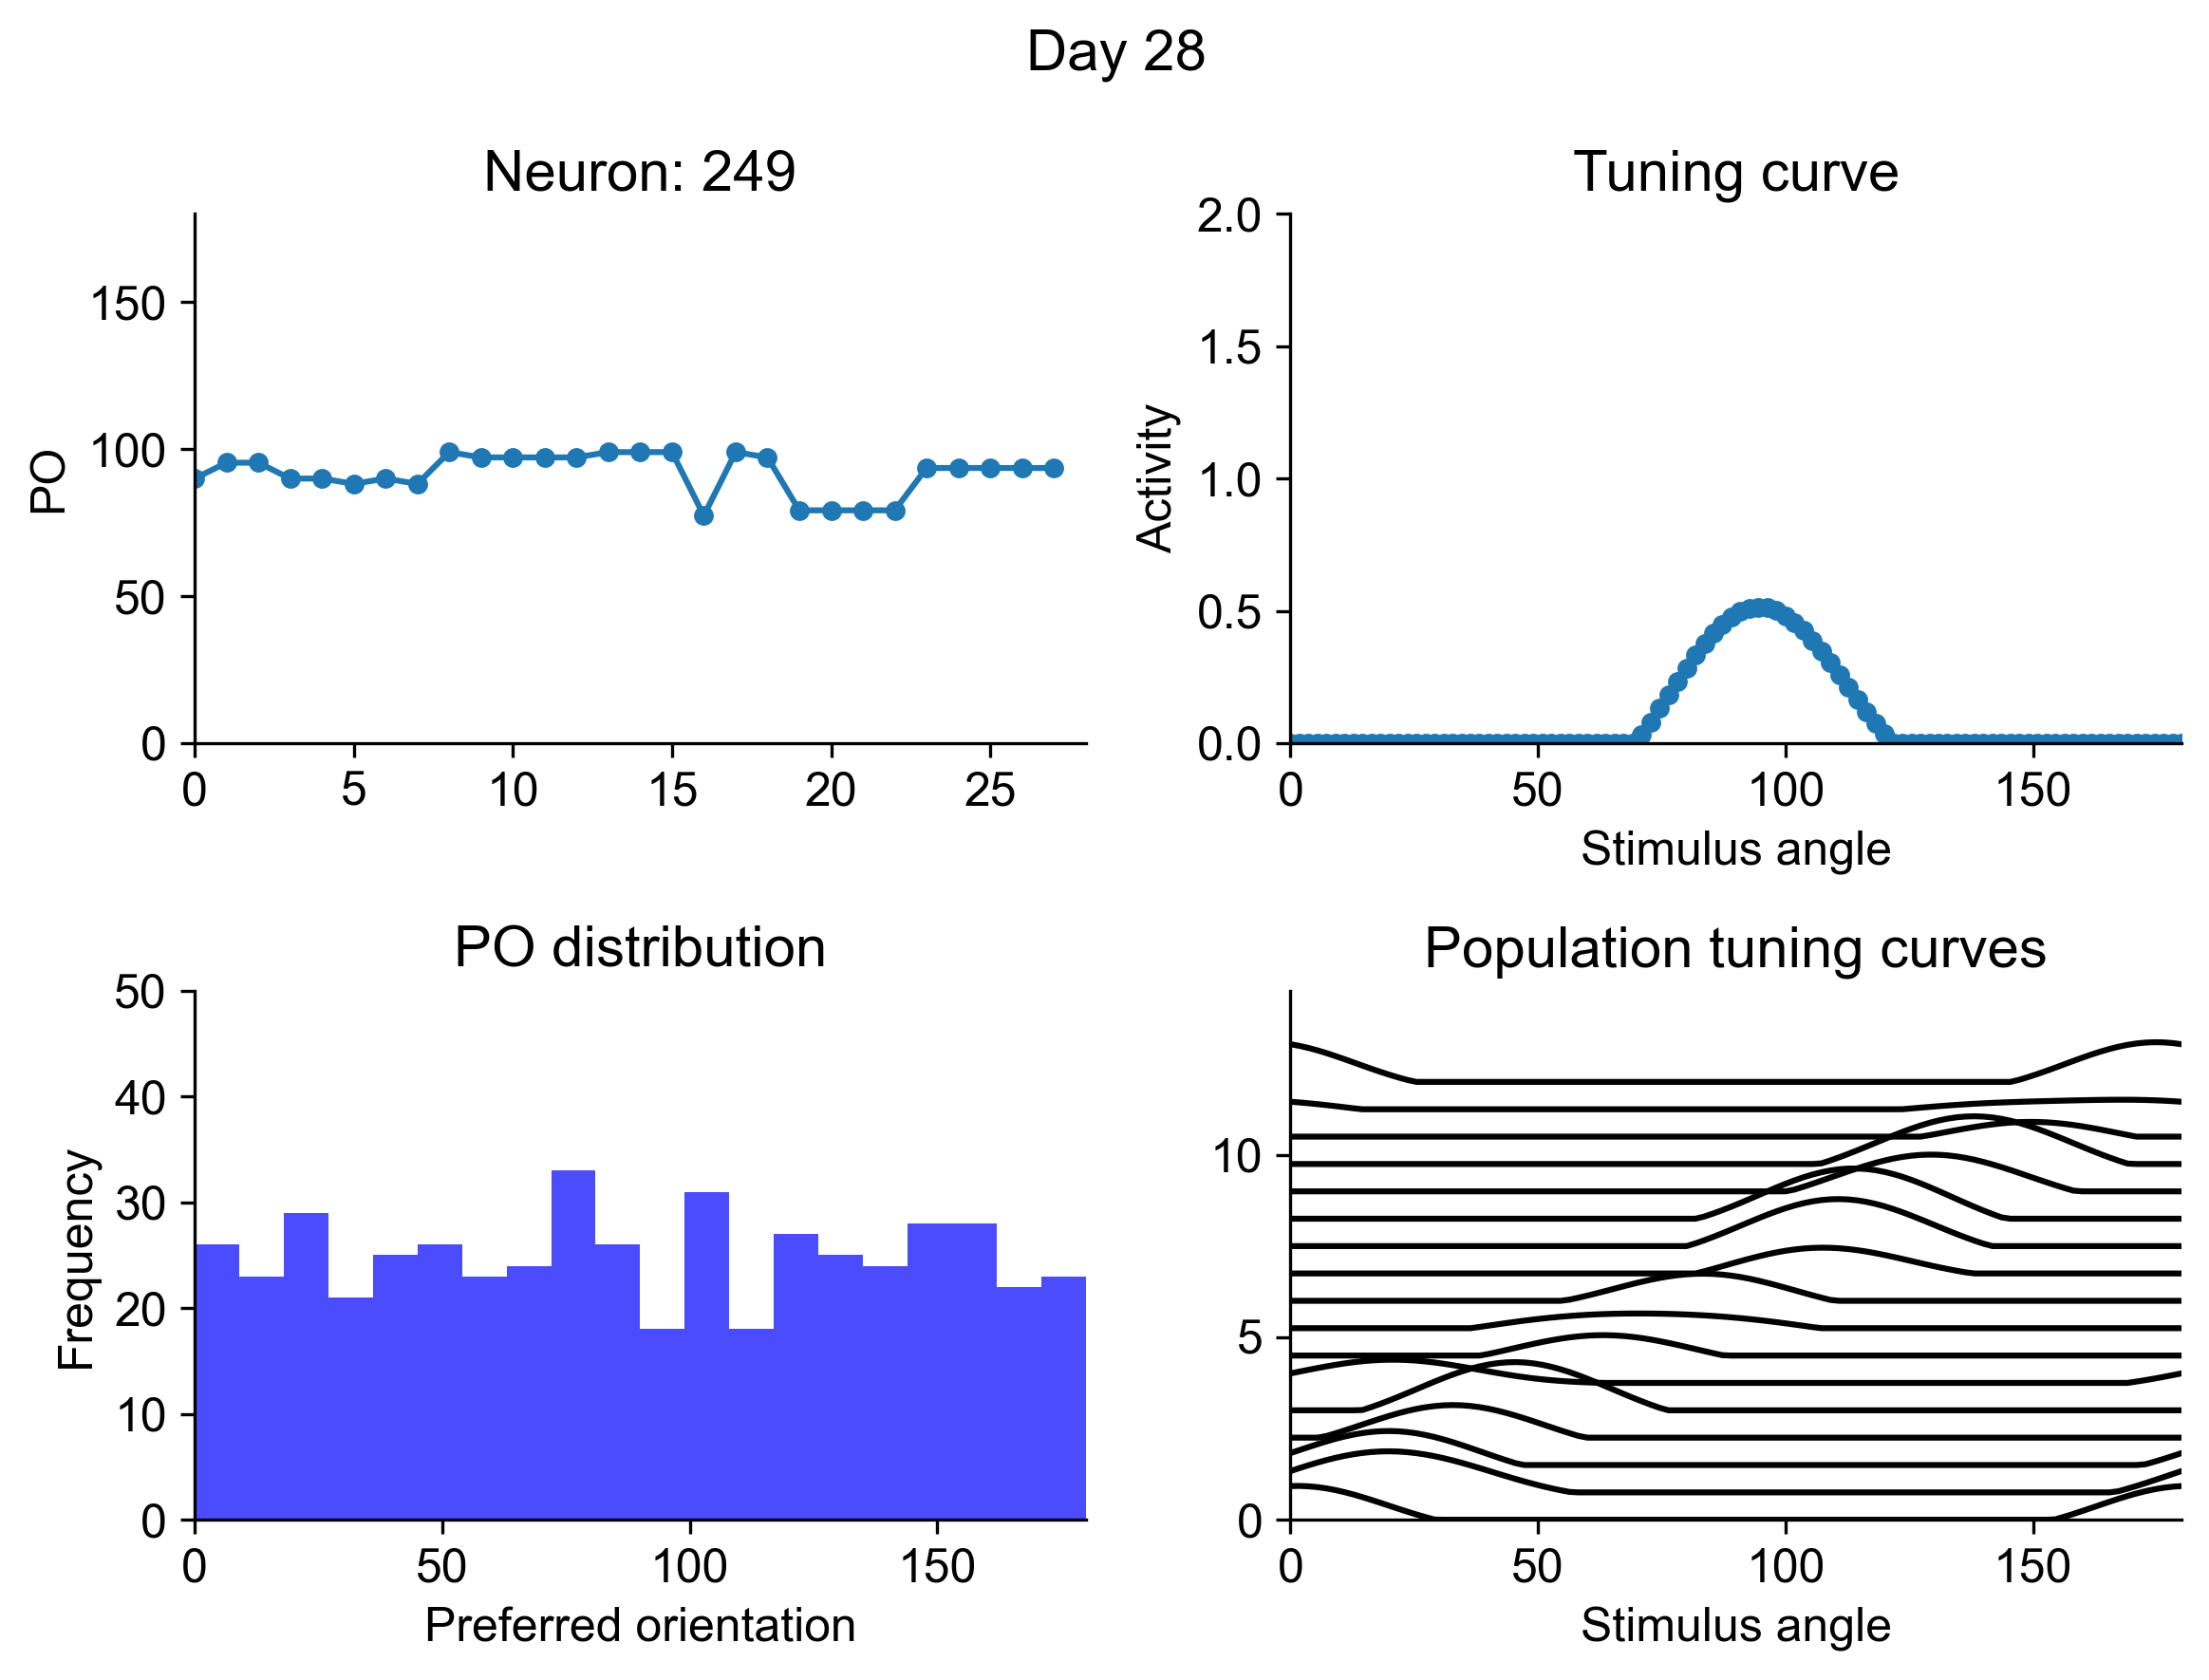

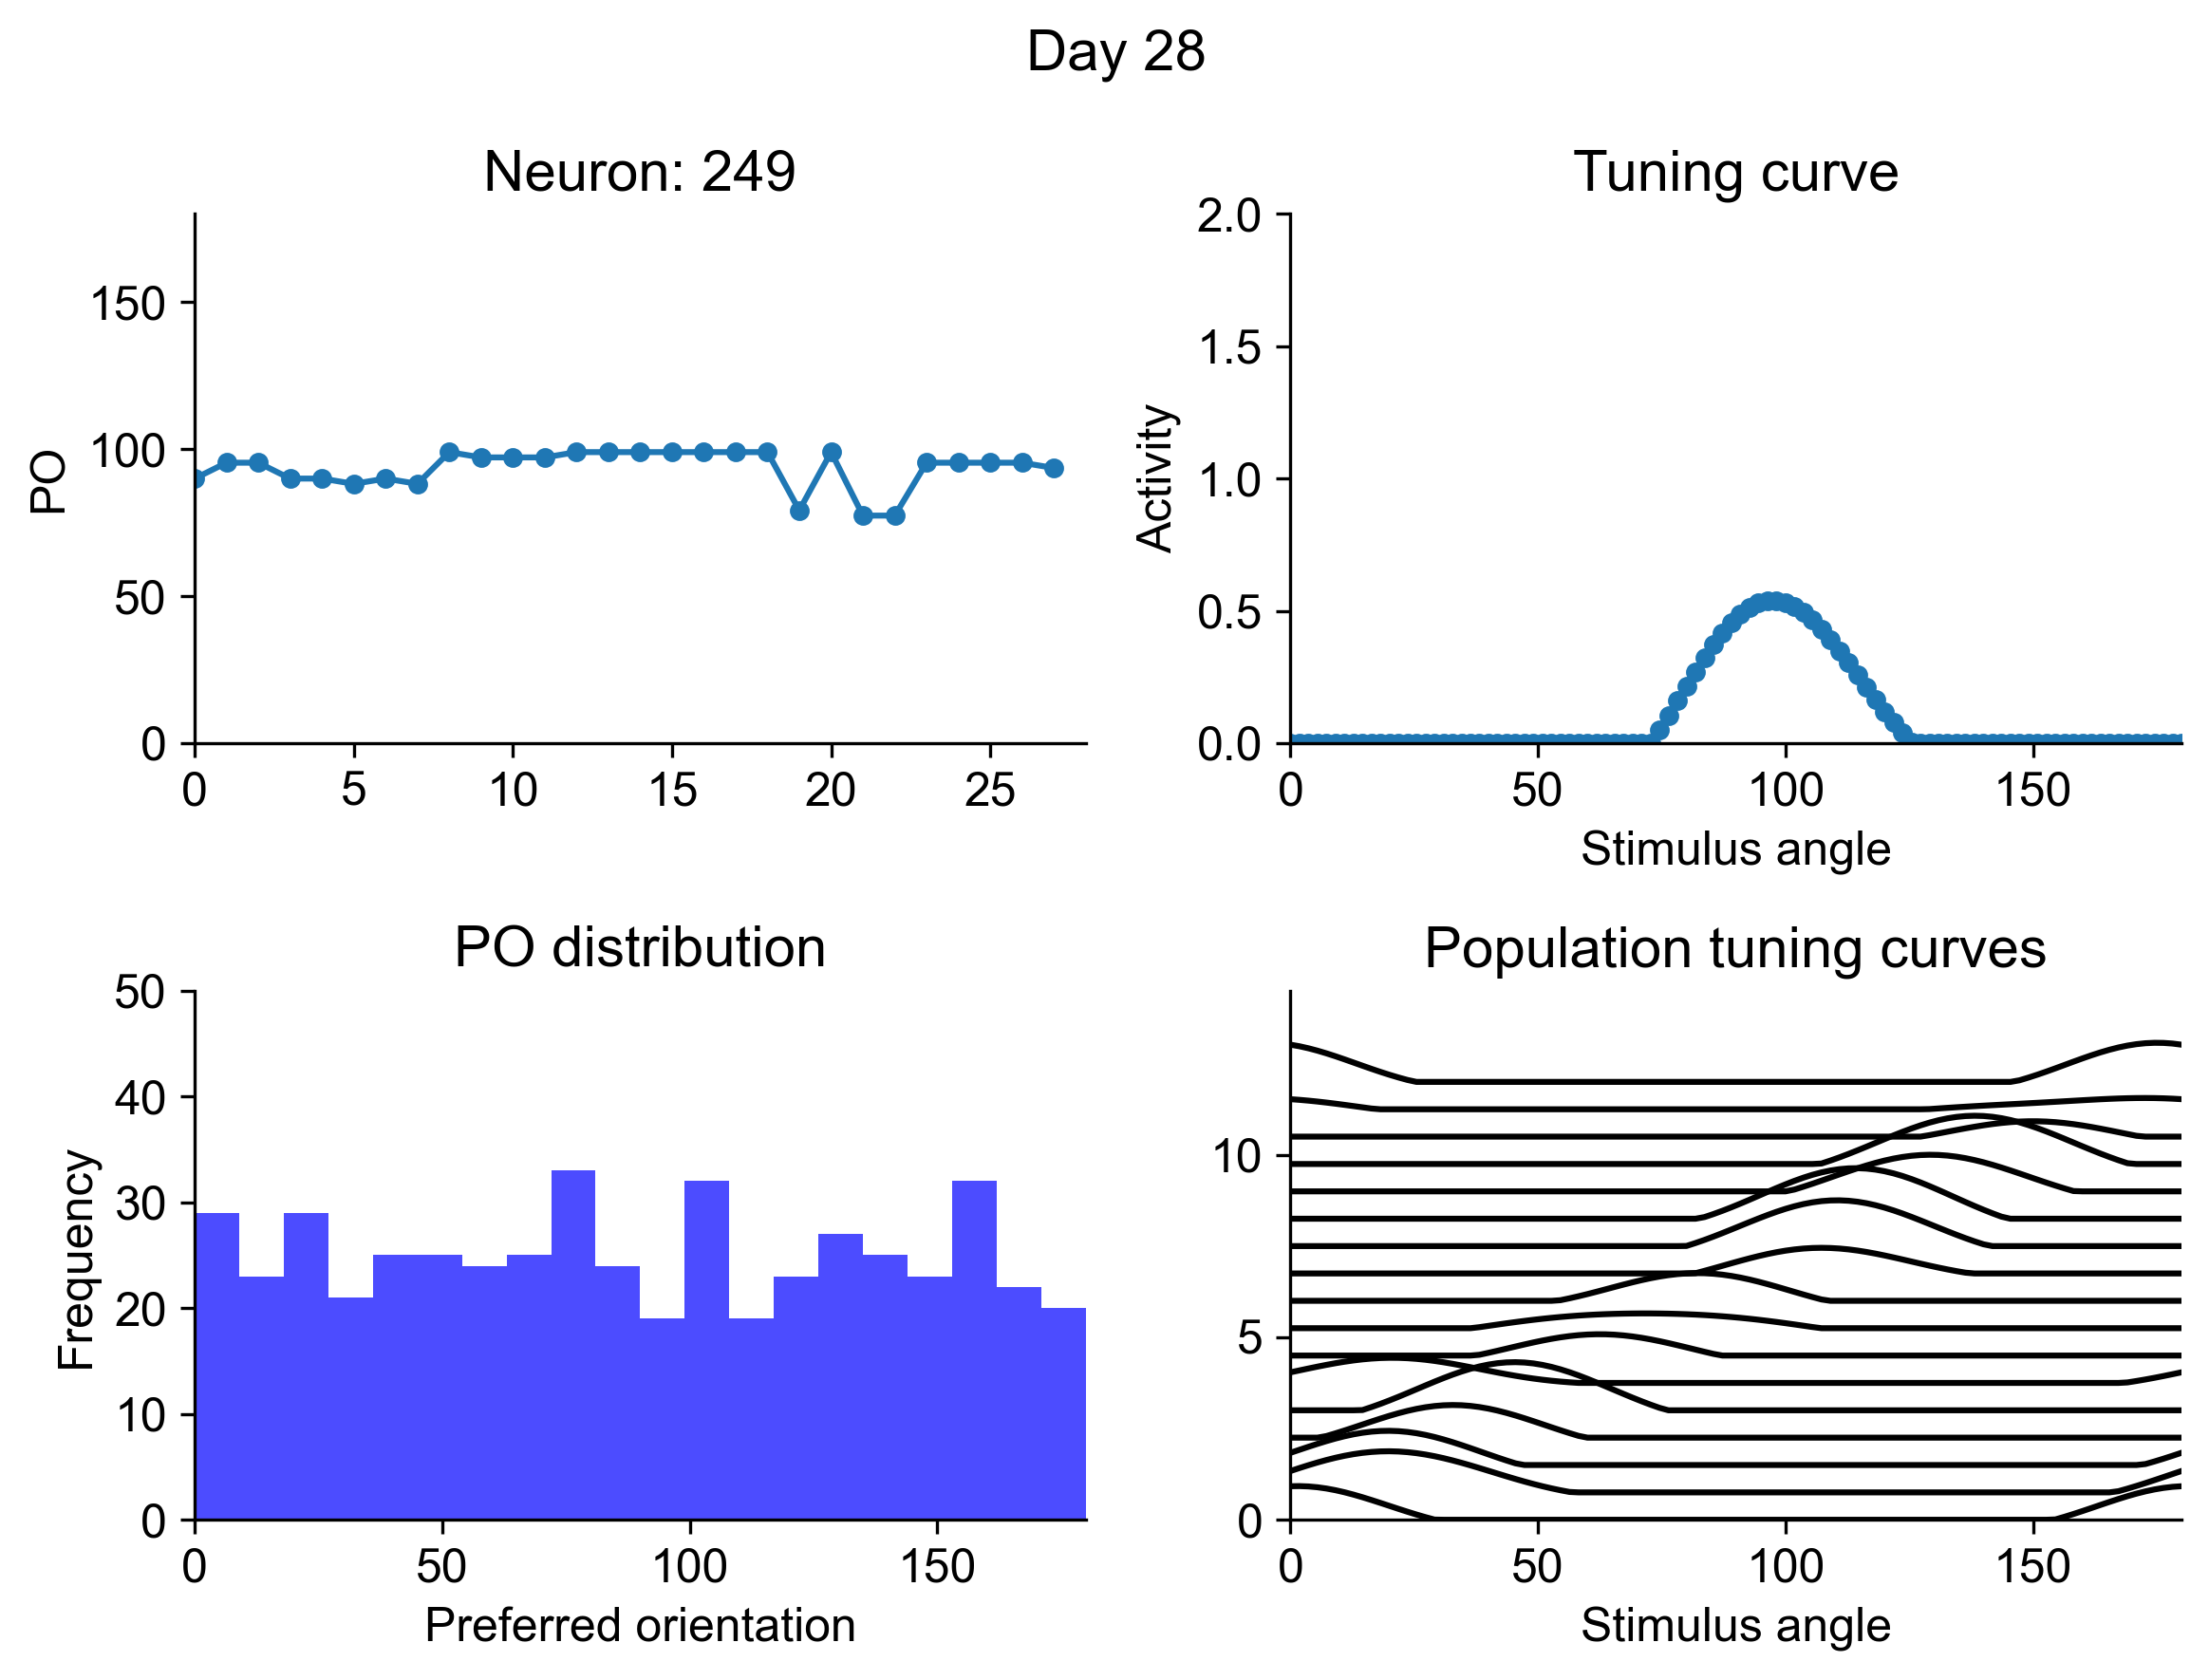

In [18]:
net.plot_animation_pop_activity(title="complete_modulation")
net_partial_mod.plot_animation_pop_activity(title="partial_modulation")

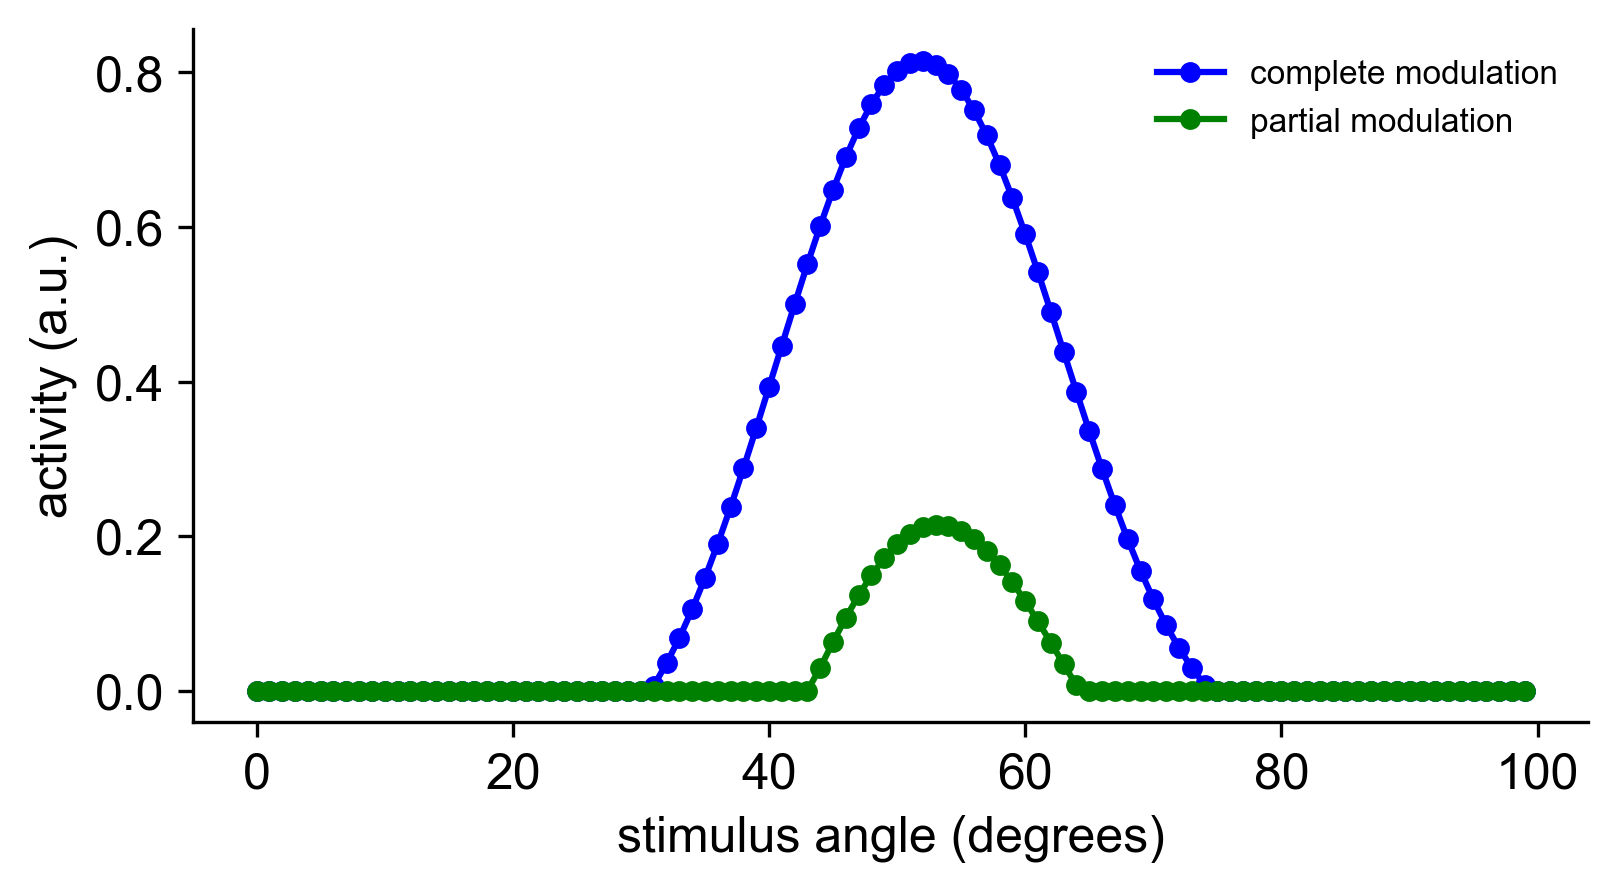

In [23]:
# Plot tuning curve of E neuron with partial and complete inhibitory modulation

probe_angle = 50

cell_idx = 249
exc_tuning_curve_day_8 = net.estimate_tuning_curves_at_day(8)[cell_idx]
exc_tuning_curve_day_8_partial_mod = net_partial_mod.estimate_tuning_curves_at_day(8)[cell_idx]

fig, axs = plt.subplots(1, 1, figsize=(6, 3), dpi=300)
axs.plot(exc_tuning_curve_day_8, c='blue', marker='o', ms=4, label='complete modulation', clip_on=False)
axs.plot(exc_tuning_curve_day_8_partial_mod, c='green', marker='o', ms=4, label='partial modulation', clip_on=False)
axs.set_xlabel('stimulus angle (degrees)')
axs.set_ylabel('activity (a.u.)')
axs.legend(frameon=False, fontsize=8)
